### Step 1: Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import albumentations as A

In [57]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn import metrics

In [31]:
import tensorflow as tf
from tensorflow import io, image, data
from tensorflow.keras import layers, Model, utils, callbacks

### Step 2: Constant

In [28]:
AUTO = data.experimental.AUTOTUNE
IMAGE_FOLD = './data/dog_vs_cat/'
IMG_HEIGH = 200
IMG_WIDTH = 200
IMG_CHANNEL = 3
BATCH_SIZE = 64

### Step 3: Load Data

In [7]:
labels = os.listdir(IMAGE_FOLD)

In [8]:
df = pd.DataFrame()

In [9]:
for label in labels:
    temp = pd.DataFrame(
        {
            'id': os.listdir(f'{IMAGE_FOLD}{label}'),
            'label': label
        }
    )
    df = pd.concat([df, temp], ignore_index=True)

In [10]:
df.shape

(24997, 2)

In [11]:
df.sample(5)

,id,label
3318,1735.jpg,Cat
6155,4289.jpg,Cat
11154,879.jpg,Cat
5500,37.jpg,Cat
5819,3987.jpg,Cat


### Step 4: Exploaring Data

#### Target Distribution

In [12]:
temp = df['label'].value_counts()

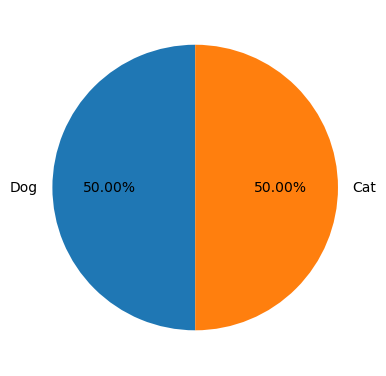

In [13]:
plt.figure(figsize=(4, 4))
plt.pie(
    temp,
    autopct='%.2f%%',
    labels=temp.index,
    startangle=90
)
plt.tight_layout()

#### Show Data

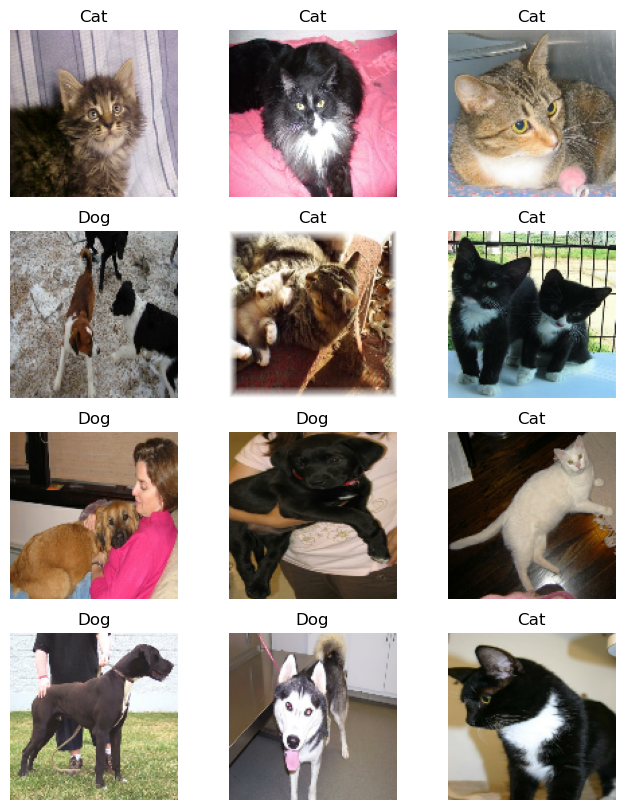

In [14]:
plt.figure(figsize=(8, 10))
for i in range(12):
    plt.subplot(4, 3, i+1)
    temp = df.sample(1)
    k = np.random.randint(0, len(df))
    img_id = temp['id'].iloc[0]
    label = temp['label'].iloc[0]
    img = io.read_file(f'{IMAGE_FOLD}{label}/{img_id}')
    img = image.decode_jpeg(img)
    img = image.resize(img, (125, 125))
    plt.imshow(img/255.0)
    plt.title(label)
    plt.axis('off')

### Step 5: Feature Engineering

In [15]:
le = LabelEncoder()

In [16]:
df['label_id'] = le.fit_transform(df['label'])

### Step 6: Preparing Data

#### Split Data

In [17]:
train, test = train_test_split(
    df,
    test_size=0.4,
    random_state=42
)

In [18]:
value, test = train_test_split(
    test,
    test_size=0.5,
    random_state=42
)

#### Albumentation

In [19]:
transform_train = A.Compose(
    [
        A.Resize(IMG_HEIGH, IMG_WIDTH),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.CoarseDropout(p=0.5),
        A.RandomBrightnessContrast(p=0.5),
        A.RandomGamma(p=0.5)
    ]
)

In [20]:
transform_test = A.Resize(IMG_HEIGH, IMG_WIDTH)

#### Build Generator

In [21]:
def generator(df, img_shape, is_train):
    def gen():
        for _, row in df.iterrows():
            img_id = row['id']
            label = row['label']
            try:
                img = cv2.imread(f'{IMAGE_FOLD}{label}/{img_id}')
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            except:
                print(f'{IMAGE_FOLD}{label}/{img_id}')
            if is_train:
                img = transform_train(image=img)['image']
            else:
                img = transform_test(image=img)['image']
            img = img.astype('float32') / 255.0
            yield img, row['label_id']

    return data.Dataset.from_generator(
        gen,
        output_signature=(
            tf.TensorSpec(shape=img_shape, dtype=tf.float32),
            tf.TensorSpec(shape=(), dtype=tf.uint8)
        )
    )

In [24]:
def get_generator(df, img_shape, batch_size, is_train=True):
    gen = generator(df, img_shape, is_train)
    gen = gen.map(
        lambda x, y: (x, tf.one_hot(y, len(le.classes_)))
    )
    if is_train:
        gen = gen.shuffle(min(len(df), 1000))
    gen = gen.batch(batch_size)
    gen = gen.prefetch(AUTO)
    return gen

In [29]:
train_generator = get_generator(train, (IMG_HEIGH, IMG_WIDTH, IMG_CHANNEL), BATCH_SIZE)
value_generator = get_generator(value, (IMG_HEIGH, IMG_WIDTH, IMG_CHANNEL), BATCH_SIZE, is_train=False)
test_generator = get_generator(test, (IMG_HEIGH, IMG_WIDTH, IMG_CHANNEL), BATCH_SIZE, is_train=False)

In [30]:
for img, label in train_generator.take(1):
    print(img.shape, label.shape)

(64, 200, 200, 3) (64, 2)


### Step 7: Model Development

#### Build Model

In [32]:
inputs = layers.Input(shape=(IMG_HEIGH, IMG_WIDTH, IMG_CHANNEL))
x = layers.Conv2D(32, 3, padding='same', activation='relu')(inputs)
x = layers.MaxPooling2D()(x)
x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
x = layers.MaxPooling2D()(x)
x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
x = layers.MaxPooling2D()(x)
x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
x = layers.MaxPooling2D()(x)
x = layers.Flatten()(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(2, activation='softmax')(x)

In [33]:
model = Model(inputs, outputs)

In [34]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 200, 200, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 200, 200, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 100, 100, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 100, 100, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 50, 50, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 50, 50, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 25, 25, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 25, 25, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 12, 12, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 9216)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │       4,719,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 512)                 │         262,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 512)                 │         262,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 2)                   │           1,0

 Total params: 5,344,834 (20.39 MB)

 Trainable params: 5,341,762 (20.38 MB)

 Non-trainable params: 3,072 (12.00 KB)

#### Compile Model

In [36]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

#### Train Model

In [37]:
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    verbose=0,
    restore_best_weights=True
)

In [38]:
lr_schedule = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.1,
    patience=3,
    verbose=0
)

In [45]:
history = model.fit(
    train_generator,
    validation_data=value_generator,
    epochs=20,
    callbacks=[early_stopping, lr_schedule],
    initial_epoch=10
)

Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 98s 412ms/step - accuracy: 0.8093 - loss: 0.4117 - val_accuracy: 0.7890 - val_loss: 0.4582 - learning_rate: 0.0010
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 106s 447ms/step - accuracy: 0.8212 - loss: 0.3974 - val_accuracy: 0.7986 - val_loss: 0.4537 - learning_rate: 0.0010
Epoch 13/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 110s 460ms/step - accuracy: 0.8305 - loss: 0.3845 - val_accuracy: 0.8308 - val_loss: 0.3768 - learning_rate: 0.0010
Epoch 14/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 112s 470ms/step - accuracy: 0.8394 - loss: 0.3649 - val_accuracy: 0.8282 - val_loss: 0.4013 - learning_rate: 0.0010
Epoch 15/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 113s 474ms/step - accuracy: 0.8422 - loss: 0.3647 - val_accuracy: 0.8246 - val_loss: 0.4091 - learning_rate: 0.0010
Epoch 16/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 114s 480ms/step - accuracy: 0.8476 - loss: 0.3489 - val_accuracy: 0.8432 - val_loss: 0.3616 - learning_rate: 0.0010
Epoch 17/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 117s 493ms/step - 

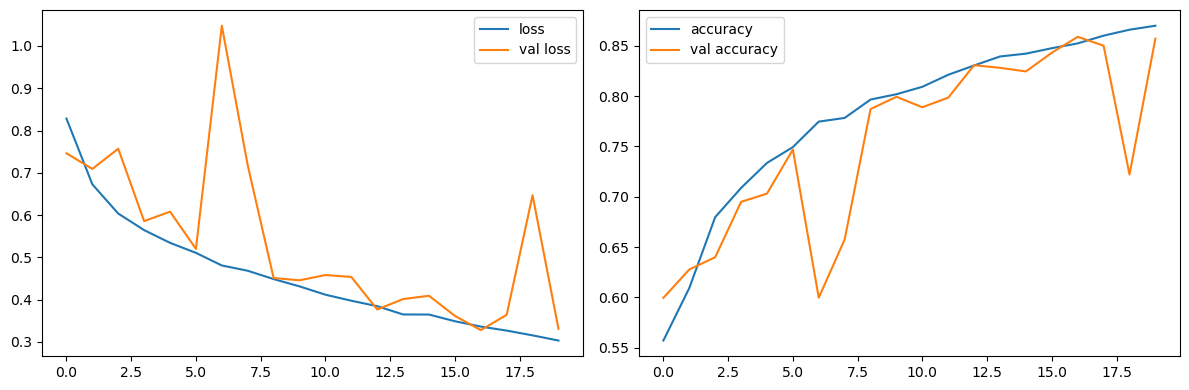

In [53]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.tight_layout()

#### Evaluate Model

In [54]:
loss, acc = model.evaluate(test_generator)

79/79 ━━━━━━━━━━━━━━━━━━━━ 33s 413ms/step - accuracy: 0.8630 - loss: 0.3170


In [55]:
print(f'test loss: {round(loss, 3)}, test accuracy: {round(acc, 3)}')

test loss: 0.317, test accuracy: 0.863


In [56]:
test_pred = model.predict(test_generator)

79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 148ms/step


In [58]:
test['pred'] = le.inverse_transform(np.argmax(test_pred, axis=1))

In [59]:
confuse_matrix = metrics.confusion_matrix(test['label'], test['pred'])

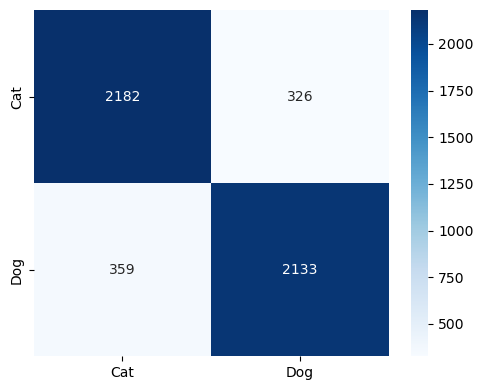

In [62]:
plt.figure(figsize=(5, 4))
sns.heatmap(
    confuse_matrix,
    fmt='d',
    annot=True,
    cmap=plt.cm.Blues,
    xticklabels=le.classes_,
    yticklabels=le.classes_,
)
plt.tight_layout()

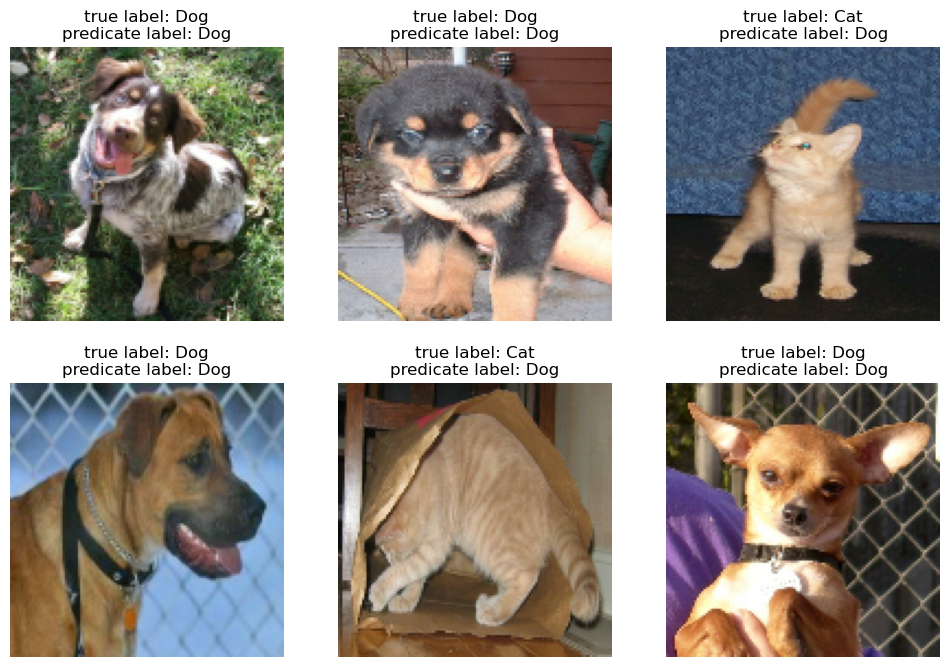

In [69]:
plt.figure(figsize=(12, 8))
for i in range(6):
    plt.subplot(2, 3, i+1)
    sample = test.sample(1)
    img_id = sample['id'].iloc[0]
    true_label = sample['label'].iloc[0]
    pred_label = sample['pred'].iloc[0]
    img = io.read_file(f'{IMAGE_FOLD}{true_label}/{img_id}')
    img = image.decode_jpeg(img)
    img = image.resize(img, (125, 125))
    plt.imshow(img/255.0)
    plt.title(f'true label: {true_label}\npredicate label: {pred_label}')
    plt.axis('off')